In [1]:
import numpy as np
import pandas as pd
import networkx as nx
from heapq import heappush, heappop
import scipy.sparse as spsp
import matplotlib.pyplot as plt
import itertools

In [2]:
class Parameter:
    def __init__(self, phi, rho, t, nu, d, N):
        self.phi = phi
        self.rho = rho
        self.t   = t
        self.nu  = nu
        self.d   = d
        self.N   = N # Number of nodes
        self.L   = (N-1)*(N-1) # Number of links

class Network:
    def __init__(self, prm):
        self.prm = prm
        _ = self.make_data()

    def make_data(self):
        self.Node2Link = {}
        self.Link2Node = {}
        self.OutLinks  = {i:[] for i in range(1, self.prm.N)}
        self.InLinks   = {i:[] for i in range(self.prm.N)}

        
        self.distance = np.zeros(self.prm.L)
        self.IT_MT_bool = np.ones(self.prm.L)
        
        link_idx = 0
        for from_node_idx in range(1, self.prm.N):
            self.Node2Link[from_node_idx] = {}
            for to_node_idx in range(self.prm.N):
                if from_node_idx == to_node_idx:
                    continue
                else:
                    

                    if abs(from_node_idx - to_node_idx) == 1:
                        # If link is IT, then the value is 0
                        self.IT_MT_bool[link_idx] = 0.0
                        
                    self.distance[link_idx] = abs(from_node_idx - to_node_idx)
                    self.Node2Link[from_node_idx][to_node_idx] = link_idx
                    self.Link2Node[link_idx] = (from_node_idx, to_node_idx)

                    self.OutLinks[from_node_idx] = self.OutLinks[from_node_idx] + [link_idx]
                    self.InLinks[to_node_idx] = self.InLinks[to_node_idx] + [link_idx]
                    
                    link_idx = link_idx + 1
        
        return True

In [56]:
# networkxを用いた可視化

def link_plot(prm, net, SP_tree):
    G_IT_link = nx.DiGraph()
    G_MT_link = nx.DiGraph()
    
    # 描画のために位置情報を与える
    pos  = {
        i : (i*35.0, 0.0)
        for i in range(prm.N)
    }

    # 隣合うノードを結ぶリンクはITリンク，それ以外はMTリンク
    for from_node_idx in range(1, prm.N):
        to_node_idx = SP_tree[from_node_idx]
        if abs(from_node_idx - to_node_idx) == 1:
            G_IT_link.add_edge(from_node_idx, to_node_idx)
        else:
            G_MT_link.add_edge(from_node_idx, to_node_idx)

    plt.figure(figsize=(12, 3.5))
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)

    plt.xlim([-12.0, (prm.N-1)*35.0+12.0])
    plt.ylim([-2.0, 4.0])

    nx.draw_networkx(G_IT_link, 
                     pos=pos, 
                     node_size=500, 
                     width=2,
                     edge_color='black',
                     node_color='white', 
                     with_labels=True, 
                     font_family = 'Times New Roman',
                     font_size=15,
                     edgecolors='black',
                     connectionstyle='arc3,rad=0.0')
    nx.draw_networkx(G_MT_link,
                     pos=pos,
                     node_size=500,
                     width=2,
                     edge_color='#FF4B00',
                     node_color='white',
                     with_labels=True,
                     font_family = 'Times New Roman',
                     font_size=15,
                     edgecolors='black',
                     connectionstyle='arc3,rad=-0.3')
    out_flow = calc_out_flow(prm, net, SP_tree)
    aj_out_flow = 0.25+out_flow*0.02
    aj_out_flow[0] = 0.0
    plt.bar([p[0] for p in pos.values()], aj_out_flow, width=10, color='black')
    return True

In [57]:
def calc_out_flow(prm, net, SP_tree):
    out_flow = np.zeros(prm.N)
    for from_node in range(1, prm.N):
        tr_node = from_node
        while tr_node != 0:
            out_flow[tr_node] = out_flow[tr_node] + prm.nu
            tr_node = SP_tree[tr_node]
    return out_flow

In [58]:
prm = Parameter(phi=20.0, rho=1.0, t=1.0, nu=10.0, d=1.0, N=17)
net = Network(prm)

In [66]:
SP_tree_a = np.array([-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
SP_tree_b = np.array([-1, 0, 1, 2, 3, 6, 7, 8, 0, 8, 9, 10, 11, 12, 13, 14, 15])
SP_tree_c = np.array([-1, 0, 1, 4, 5, 0, 5, 6, 9, 10, 5, 10, 11, 12, 13, 14, 15])
SP_tree_d = np.array([-1, 0, 1, 4, 5, 0, 5, 6, 9, 5, 9, 10, 13, 9, 13, 14, 15])
SP_tree_e = np.array([-1, 0, 1, 2, 3, 4, 7, 8, 9, 10, 0, 10, 11, 12, 13, 14, 15])
SP_tree_f = np.array([-1, 0, 1, 2, 5, 6, 7, 0, 7, 8, 9, 12, 13, 7, 13, 14, 15])

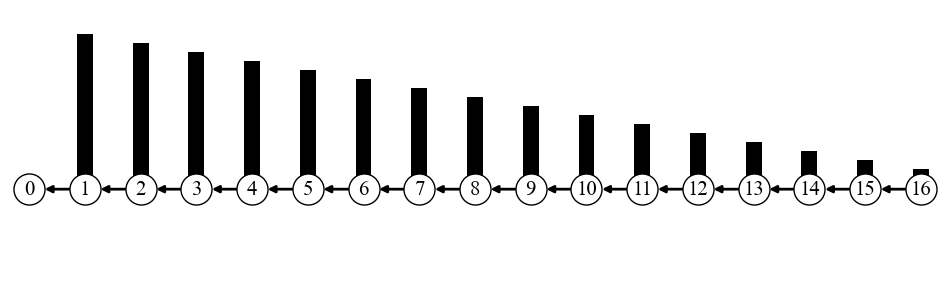

In [67]:
link_plot(prm, net, SP_tree_a)
path= 'image3/HS_a.pdf'
plt.savefig(path, format='pdf', bbox_inches='tight', dpi=400)

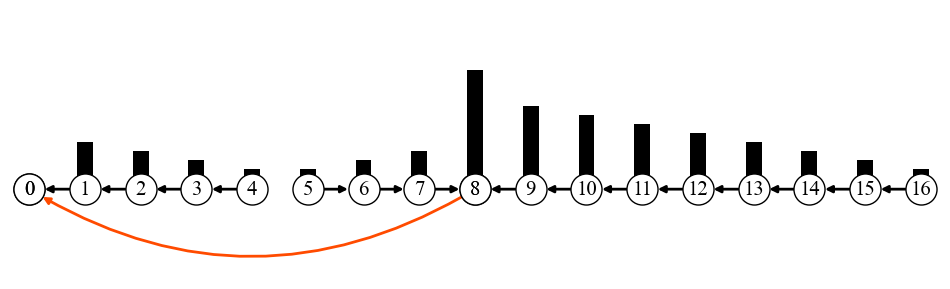

In [68]:
link_plot(prm, net, SP_tree_b)
path= 'image3/HS_b.pdf'
plt.savefig(path, format='pdf', bbox_inches='tight', dpi=400)

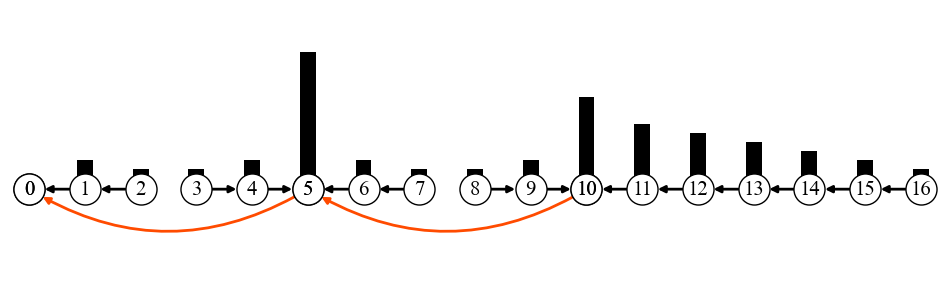

In [69]:
link_plot(prm, net, SP_tree_c)
path= 'image3/HS_c.pdf'
plt.savefig(path, format='pdf', bbox_inches='tight', dpi=400)

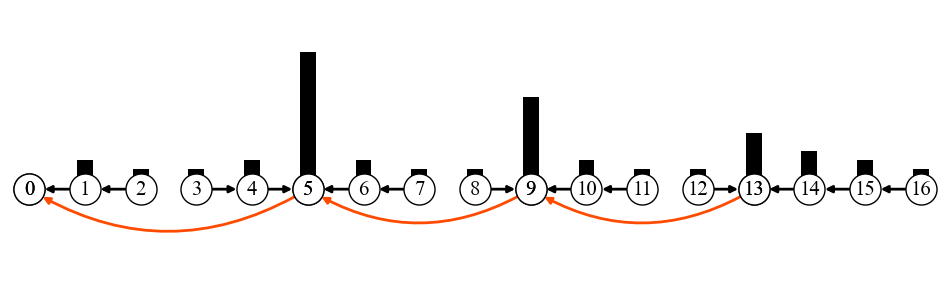

In [70]:
link_plot(prm, net, SP_tree_d)
path= 'image3/HS_d.pdf'
plt.savefig(path, format='pdf', bbox_inches='tight', dpi=400)

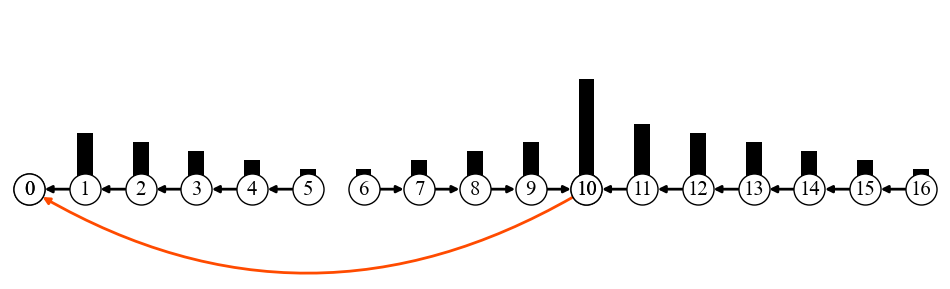

In [71]:
link_plot(prm, net, SP_tree_e)
path= 'image3/HS_e.pdf'
plt.savefig(path, format='pdf', bbox_inches='tight', dpi=400)

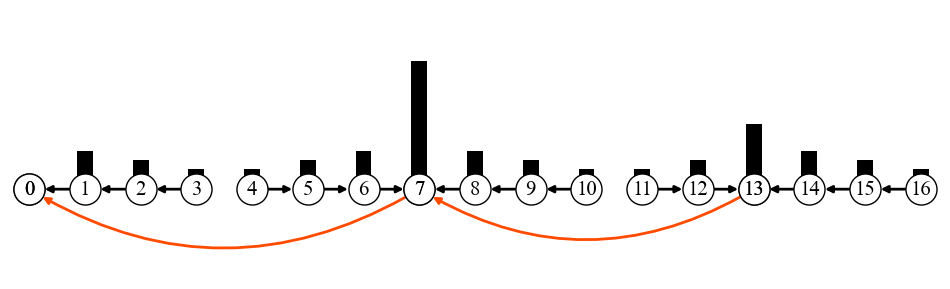

In [72]:
link_plot(prm, net, SP_tree_f)
path= 'image3/HS_f.pdf'
plt.savefig(path, format='pdf', bbox_inches='tight', dpi=400)